In [8]:
from langgraph.graph import StateGraph,END
from typing import TypedDict
import random
from typing import List

In [9]:
class AgentState:
    name:str
    counter:int
    number:List[int]

In [10]:
def chaoban(state:AgentState)-> AgentState:
    """Phuong thuc chao"""
    state['name'] = f"Chao {state["name"]}"
    state['counter'] = 0
    return state

def  random_node(state:AgentState)-> AgentState:
    """So ngau nhien"""
    state['number'].append(random.randint(0,10))
    state['counter']+=1
    return state

def should_continue(state:AgentState)->AgentState:
    """kiem tra thu co the tiep tuc khong"""
    if state['counter']<5:
        print("Enter Loop", state['counter'])
        return "loop"
    else:
        return "exit"

In [11]:
graph = StateGraph(AgentState)
graph.add_node('chaoban',chaoban)
graph.add_node('random',random_node)
graph.add_edge('chaoban','random')
graph.add_conditional_edges('random',
                            should_continue,
                            {
                                'loop':'random',
                                'exit':END
                            })
graph.set_entry_point('chaoban')
app = graph.compile()

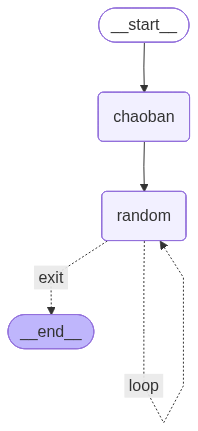

In [15]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png( )))

In [16]:
app.invoke({"name":"Xon","number":[],"counter":-1})

Enter Loop 1
Enter Loop 2
Enter Loop 3
Enter Loop 4


{'name': 'Chao Xon', 'counter': 5, 'number': [3, 3, 8, 8, 4]}